# Trail Making Task (TMT) Analysis Pipeline

This notebook performs a comprehensive analysis of the Trail Making Task (TMT), comparing **Part A** (Visuomotor Speed) and **Part B** (Executive Function/Set-Shifting).

## Objectives
1. **Quality Control:** Apply strict inclusion criteria (valid trials for both Part A and Part B).
2. **Comparative Statistics:** Analyze differences in Reaction Time (RT) and Error Rates.
3. **Cognitive Metrics:** Calculate the "Shifting Cost" (Difference B-A) and "Executive Ratio" (B/A).
4. **Correlations:** Explore the relationship between motor speed and executive functioning.

## Input
- `analysis.csv`: Raw TMT output file.

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Set visual style
sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams['figure.figsize'] = (10, 6)

## 1. Data Loading and Strict Filtering

We load the raw data and perform the following cleaning steps:
1. Filter for `is_valid == True`.
2. Identify Part A and Part B trials.
3. Pivot the data to have one row per subject.
4. **Strict Inclusion:** Drop any subject that does not have valid data for *both* parts.

In [15]:
import pandas as pd
import numpy as np

# Load Data
try:
    df_raw = pd.read_csv('/home/gus/Documents/REPOS/datapruebas_analysis/data/hand_analysis/2026-01-12_11-52-32/analysis.csv')
    print(f"Raw data loaded. Shape: {df_raw.shape}")
except FileNotFoundError:
    print("Error: 'analysis.csv' not found. Please upload the file.")

# 1. Filter Valid Trials
df_valid = df_raw[df_raw['is_valid'] == True].copy()

# drop invalid age
df_valid = df_valid[df_valid['age'] > 0]  

# 2. Map Trial Types
def get_part(trial_type):
    tt = str(trial_type).upper()
    if 'PART_A' in tt: return 'A'
    if 'PART_B' in tt: return 'B'
    return None

df_valid['Part'] = df_valid['trial_type'].apply(get_part)
df_valid = df_valid.dropna(subset=['Part'])  # Remove non-TMT trials if any

# 3. Pivot Data (Subject x Part)
# A) Time (Media de RT)
pivot_rt = df_valid.pivot_table(index='subject_id', columns='Part', values='non_cut_rt')
# B) Errors (Media de Errores)
pivot_err = df_valid.pivot_table(index='subject_id', columns='Part', values='non_cut_wrong_targets_touches')
# C) NUEVO: Count (Cantidad de trials válidos)
# Usamos 'count' sobre cualquier columna (ej: 'trial_id') para contar filas
pivot_count = df_valid.pivot_table(index='subject_id', columns='Part', values='trial_id', aggfunc='count')

# Rename columns
pivot_rt.columns = [f'Time_{c}' for c in pivot_rt.columns]
pivot_err.columns = [f'Errors_{c}' for c in pivot_err.columns]
pivot_count.columns = [f'ValidTrials_{c}' for c in pivot_count.columns]

# Merge Time, Errors and Counts
df_tmt = pivot_rt.join(pivot_err).join(pivot_count)

# 4. Apply Strict Filter (Must have at least 1 valid A AND 1 valid B)
initial_n = len(df_tmt)
df_tmt = df_tmt.dropna()
final_n = len(df_tmt)

print(f"Subjects with valid data (at least one part): {initial_n}")
print(f"Subjects with COMPLETE data (Strict Criteria): {final_n}")
print(f"Excluded: {initial_n - final_n}")

# 5. Feature Engineering
# Calculate Completion Percentage (Assuming 10 trials total)
df_tmt['Pct_A'] = (df_tmt['ValidTrials_A'] / 10 * 100).clip(upper=100)
df_tmt['Pct_B'] = (df_tmt['ValidTrials_B'] / 10 * 100).clip(upper=100)

# Unit Conversion (ms to seconds check)
if df_tmt['Time_A'].mean() > 1000:
    print("\nCreating columns in Seconds (converted from ms)...")
    df_tmt['Time_A_sec'] = df_tmt['Time_A'] / 1000
    df_tmt['Time_B_sec'] = df_tmt['Time_B'] / 1000
else:
    df_tmt['Time_A_sec'] = df_tmt['Time_A']
    df_tmt['Time_B_sec'] = df_tmt['Time_B']

df_tmt.head()

Raw data loaded. Shape: (6727, 112)
Subjects with valid data (at least one part): 343
Subjects with COMPLETE data (Strict Criteria): 329
Excluded: 14

Creating columns in Seconds (converted from ms)...


,Time_A,Time_B,Errors_A,Errors_B,ValidTrials_A,ValidTrials_B,Pct_A,Pct_B,Time_A_sec,Time_B_sec
subject_id,,,,,,,,,,
000b56b2-809c-4acf-9139-1265ecfa284e,24431.666667,24598.500000,0.333333,0.000000,3.0,2.0,30.0,20.0,24.431667,24.598500
026d71e0-ded4-488b-ab2a-9c9b7bed0eba,20627.600000,24491.000000,0.100000,1.111111,10.0,9.0,100.0,90.0,20.627600,24.491000
03ac286b-6c27-4427-bbed-0f0e607a3ac3,20406.888889,22795.444444,0.222222,0.333333,9.0,9.0,90.0,90.0,20.406889,22.795444
03ed4d2a-44f7-47f9-a966-712dfb380a9a,20451.800000,24312.600000,0.700000,1.400000,10.0,10.0,100.0,100.0,20.451800,24.312600
046572d0-518e-4207-b8af-92b01233f4de,24570.000000,24504.000000,0.333333,0.000000,3.0,1.0,30.0,10.0,24.570000,24.504000


/tmp/ipykernel_452375/1757813481.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


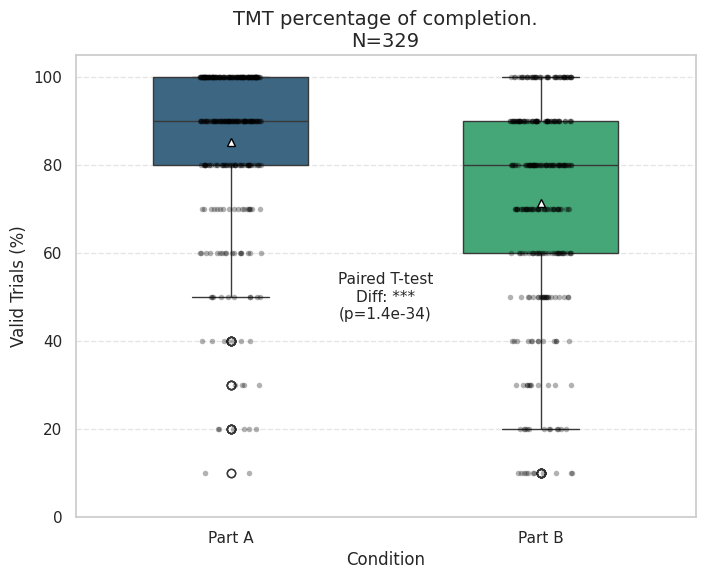

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Preparar datos para seaborn (formato largo)
melted_comp = df_tmt[['Pct_A', 'Pct_B']].reset_index().melt(
    id_vars='subject_id', 
    var_name='Condition', 
    value_name='Completion_Rate'
)
melted_comp['Condition'] = melted_comp['Condition'].map({'Pct_A': 'Part A', 'Pct_B': 'Part B'})

# Test estadístico
t_stat, p_val = stats.ttest_rel(df_tmt['Pct_A'], df_tmt['Pct_B'])

# Plot
plt.figure(figsize=(8, 6))

# A) Boxplot
sns.boxplot(
    data=melted_comp,
    x='Condition',
    y='Completion_Rate',
    palette="viridis",
    width=0.5,
    showmeans=True,
    meanprops={"marker":"^", "markerfacecolor":"white", "markeredgecolor":"black"}
)

# B) Stripplot (Puntos)
sns.stripplot(
    data=melted_comp,
    x='Condition',
    y='Completion_Rate',
    color='black',
    alpha=0.3,
    jitter=True,
    size=4
)

plt.title(f'TMT percentage of completion.\nN={len(df_tmt)}', fontsize=14)
plt.ylabel('Valid Trials (%)')
plt.ylim(0, 105) # Ajustado para que se vea desde abajo si hay gente con pocos trials
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Texto estadístico
sig_text = "***" if p_val < 0.001 else ("**" if p_val < 0.01 else ("*" if p_val < 0.05 else "ns"))
plt.text(0.5, 50, f'Paired T-test\nDiff: {sig_text}\n(p={p_val:.1e})', 
         ha='center', va='center', fontsize=11, 
         bbox=dict(facecolor='white', alpha=0.9, boxstyle='round'))

plt.show()

## 2. Statistical Comparison (Part A vs. Part B)

We use **Paired Samples T-Tests** to determine if the increase in time and errors in Part B is statistically significant.

In [17]:
# Descriptive Stats
desc = df_tmt[['Time_A_sec', 'Time_B_sec', 'Errors_A', 'Errors_B']].describe().round(2)
display(desc)

# Paired T-Tests
t_time, p_time = stats.ttest_rel(df_tmt['Time_A_sec'], df_tmt['Time_B_sec'])
t_err, p_err = stats.ttest_rel(df_tmt['Errors_A'], df_tmt['Errors_B'])

# Cohen's d (Effect Size) for Time
diff = df_tmt['Time_B_sec'] - df_tmt['Time_A_sec']
cohens_d = diff.mean() / diff.std()

print("--- Statistical Results ---")
print(f"TIME:   Part A vs Part B | t({final_n-1}) = {t_time:.2f}, p = {p_time:.4e}, d = {cohens_d:.2f}")
print(f"ERRORS: Part A vs Part B | t({final_n-1}) = {t_err:.2f}, p = {p_err:.4f}")

,Time_A_sec,Time_B_sec,Errors_A,Errors_B
count,329.00,329.00,329.00,329.00
mean,21.87,23.81,0.48,0.46
std,2.17,1.19,0.77,0.73
min,14.71,18.00,0.00,0.00
25%,20.45,23.50,0.10,0.00
50%,22.38,24.22,0.25,0.20
75%,23.59,24.59,0.56,0.62
max,24.90,24.98,7.50,8.00


--- Statistical Results ---
TIME:   Part A vs Part B | t(328) = -19.34, p = 3.7653e-56, d = 1.07
ERRORS: Part A vs Part B | t(328) = 0.56, p = 0.5744


/tmp/ipykernel_452375/1667974726.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Condition', y='Time (s)', data=plot_data, inner='quartile', palette='Set2')


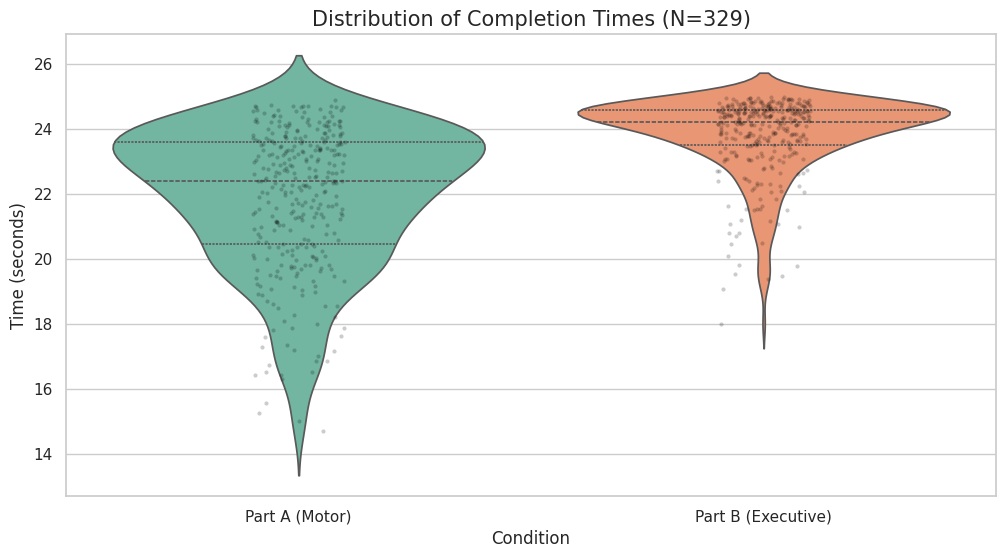

In [18]:
# Visualization: Reaction Time Distribution
plt.figure(figsize=(12, 6))

# Melt data for plotting
plot_data = df_tmt.melt(value_vars=['Time_A_sec', 'Time_B_sec'], 
                        var_name='Condition', value_name='Time (s)')
plot_data['Condition'] = plot_data['Condition'].map({'Time_A_sec': 'Part A (Motor)', 'Time_B_sec': 'Part B (Executive)'})

sns.violinplot(x='Condition', y='Time (s)', data=plot_data, inner='quartile', palette='Set2')
sns.stripplot(x='Condition', y='Time (s)', data=plot_data, color='black', alpha=0.2, jitter=True, size=3)

plt.title(f"Distribution of Completion Times (N={final_n})", fontsize=15)
plt.ylabel("Time (seconds)")
plt.show()

## 3. Executive Function Metrics

To isolate executive function from motor speed, we calculate:
1.  **Shifting Cost (Difference):** $B - A$. Represents the specific time cost of the switching rule.
2.  **Ratio:** $B / A$. A ratio > 2.5 or 3.0 represents significant difficulty with set-shifting relative to baseline motor speed.

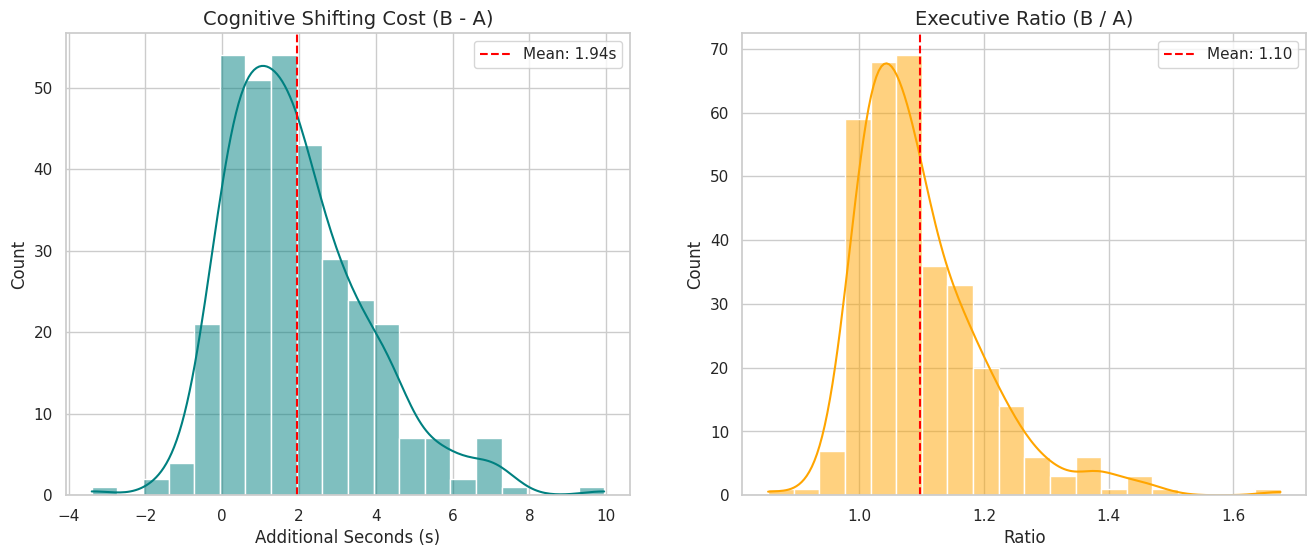

In [19]:
df_tmt['Shift_Cost'] = df_tmt['Time_B_sec'] - df_tmt['Time_A_sec']
df_tmt['Ratio_BA'] = df_tmt['Time_B_sec'] / df_tmt['Time_A_sec']

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Histogram of Cost
sns.histplot(df_tmt['Shift_Cost'], kde=True, ax=ax[0], color='teal', bins=20)
ax[0].set_title("Cognitive Shifting Cost (B - A)", fontsize=14)
ax[0].set_xlabel("Additional Seconds (s)")
ax[0].axvline(df_tmt['Shift_Cost'].mean(), color='red', linestyle='--', label=f"Mean: {df_tmt['Shift_Cost'].mean():.2f}s")
ax[0].legend()

# Histogram of Ratio
sns.histplot(df_tmt['Ratio_BA'], kde=True, ax=ax[1], color='orange', bins=20)
ax[1].set_title("Executive Ratio (B / A)", fontsize=14)
ax[1].set_xlabel("Ratio")
ax[1].axvline(df_tmt['Ratio_BA'].mean(), color='red', linestyle='--', label=f"Mean: {df_tmt['Ratio_BA'].mean():.2f}")
ax[1].legend()

plt.show()

## 4. Motor-Cognitive Correlation

Is performance in Part B simply a function of how fast the subject moves? 
We correlate Part A (Motor Baseline) with Part B (Executive) to find out.

* **High Correlation:** Part B performance is strongly driven by motor speed.
* **Outliers above the line:** Subjects with disproportionate executive deficits.

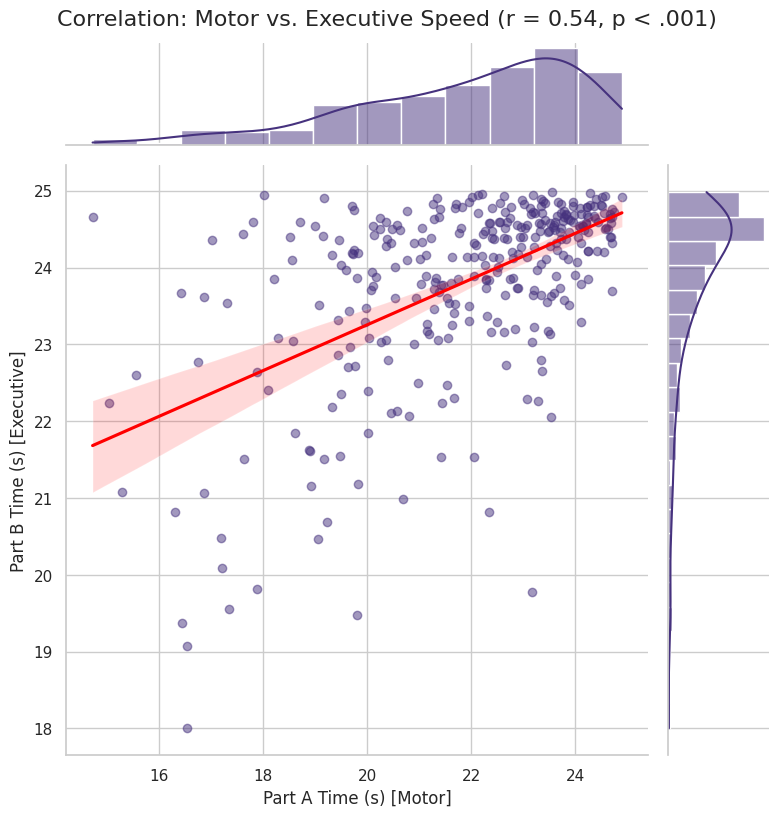

In [20]:
r, p_corr = stats.pearsonr(df_tmt['Time_A_sec'], df_tmt['Time_B_sec'])

g = sns.jointplot(x='Time_A_sec', y='Time_B_sec', data=df_tmt, kind='reg', 
                  height=8, scatter_kws={'alpha':0.5}, line_kws={'color':'red'})

g.fig.suptitle(f"Correlation: Motor vs. Executive Speed (r = {r:.2f}, p < .001)", fontsize=16, y=1.02)
g.set_axis_labels("Part A Time (s) [Motor]", "Part B Time (s) [Executive]", fontsize=12)
plt.show()

## 5. Speed-Accuracy Trade-off Analysis

Do faster participants make more errors in the complex task (Part B)?

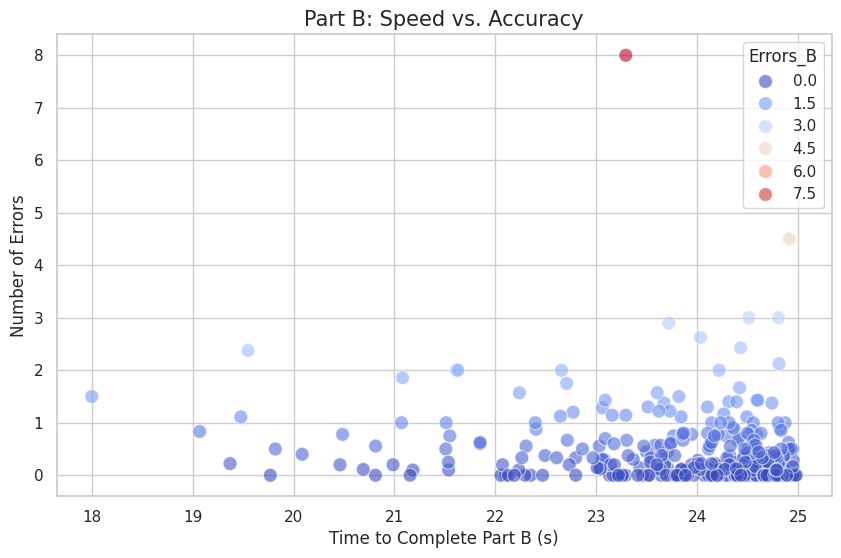

Correlation between Speed and Errors: r = -0.14 (p=0.0125)
Negative correlation: Slower subjects tend to make fewer errors (or faster subjects make more).


In [21]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Time_B_sec', y='Errors_B', data=df_tmt, alpha=0.6, s=100, hue='Errors_B', palette='coolwarm')
plt.title("Part B: Speed vs. Accuracy", fontsize=15)
plt.xlabel("Time to Complete Part B (s)")
plt.ylabel("Number of Errors")
plt.show()

# Correlation check
r_sa, p_sa = stats.pearsonr(df_tmt['Time_B_sec'], df_tmt['Errors_B'])
print(f"Correlation between Speed and Errors: r = {r_sa:.2f} (p={p_sa:.4f})")
if r_sa < 0:
    print("Negative correlation: Slower subjects tend to make fewer errors (or faster subjects make more).")
else:
    print("Positive correlation: Slower subjects also make more errors (General Performance Deficit).")

## 6. Generated Report Paragraph
Standard text for inclusion in results section.

In [22]:
print(f"""
Data from {final_n} participants met the strict quality control criteria for the Trail Making Task 
(requiring valid completions for both Part A and Part B). 

The average time to complete Part A was {df_tmt['Time_A_sec'].mean():.2f} s (SD = {df_tmt['Time_A_sec'].std():.2f}), 
while the more cognitively demanding Part B required an average of {df_tmt['Time_B_sec'].mean():.2f} s (SD = {df_tmt['Time_B_sec'].std():.2f}). 

A paired t-test confirmed that the increase in duration for Part B was statistically significant 
(t = {t_time:.2f}, p < .001, Cohen's d = {cohens_d:.2f}). 

The mean shifting cost (B - A) was {df_tmt['Shift_Cost'].mean():.2f} s, 
and the average B/A ratio was {df_tmt['Ratio_BA'].mean():.2f}.
""")


Data from 329 participants met the strict quality control criteria for the Trail Making Task 
(requiring valid completions for both Part A and Part B). 

The average time to complete Part A was 21.87 s (SD = 2.17), 
while the more cognitively demanding Part B required an average of 23.81 s (SD = 1.19). 

A paired t-test confirmed that the increase in duration for Part B was statistically significant 
(t = -19.34, p < .001, Cohen's d = 1.07). 

The mean shifting cost (B - A) was 1.94 s, 
and the average B/A ratio was 1.10.

